In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
data = california.frame

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [17]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<Axes: xlabel='Longitude', ylabel='Latitude'>

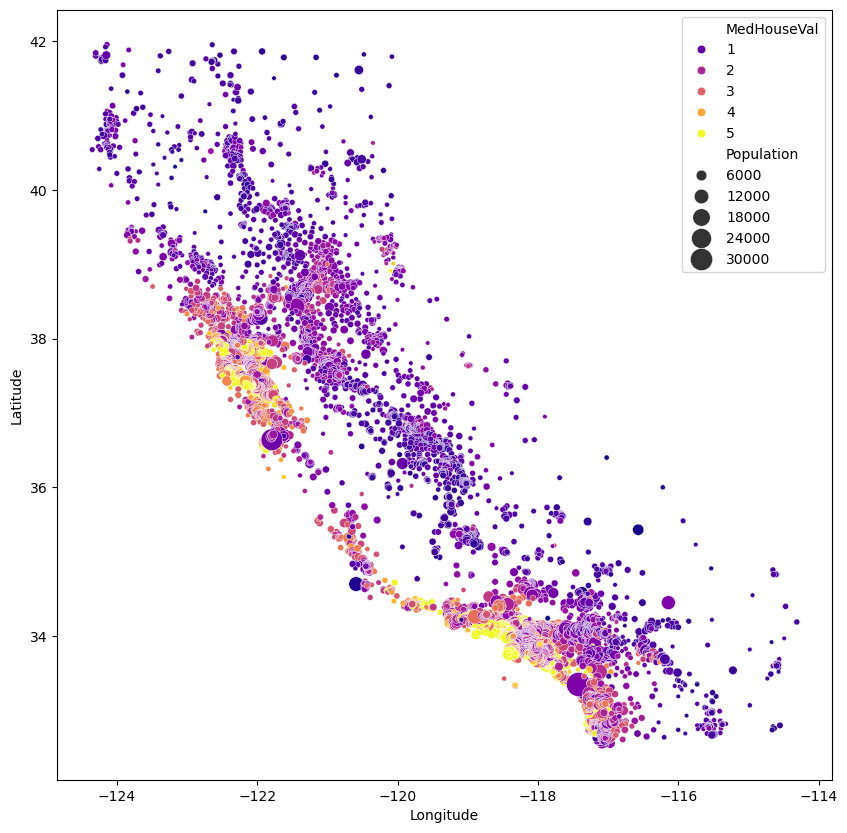

In [18]:
plt.figure(figsize=(10,10))

sns.scatterplot(
    x="Longitude",
    y="Latitude",
    hue="MedHouseVal",
    palette="plasma",
    data=data,
    size="Population",
    sizes=(10, 300)
)

In [19]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data.Longitude, data.Latitude),
    crs="EPSG:4326"  # WGS84 (GPS coordinate system)
)

In [20]:
gdf

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,geometry
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,POINT (-122.23 37.88)
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,POINT (-122.22 37.86)
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,POINT (-122.24 37.85)
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,POINT (-122.25 37.85)
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,POINT (-122.25 37.85)
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,POINT (-121.09 39.48)
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,POINT (-121.21 39.49)
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,POINT (-121.22 39.43)
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,POINT (-121.32 39.43)


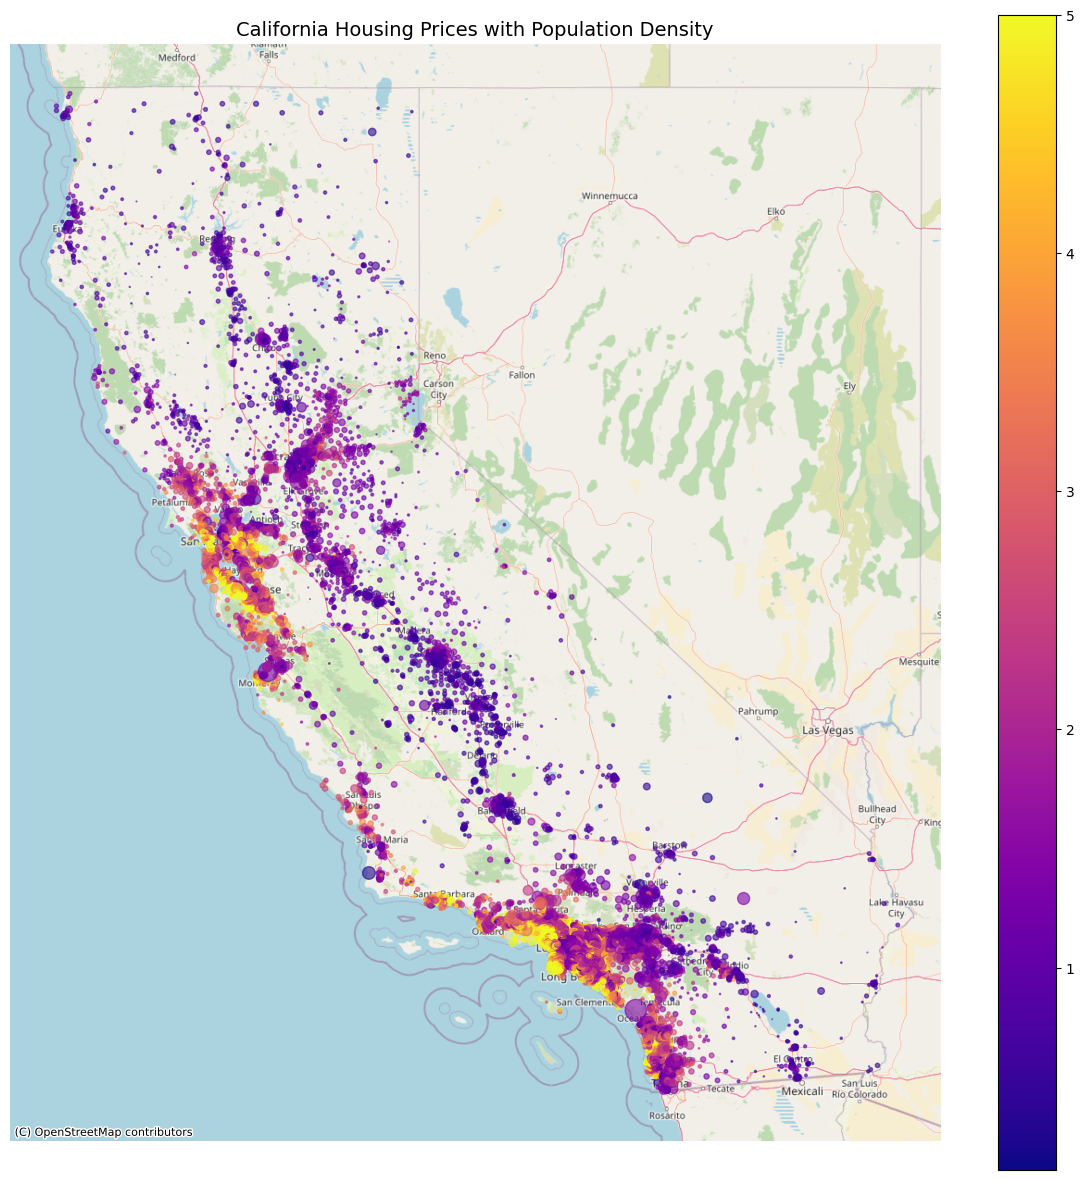

In [21]:
import contextily as ctx

gdf = gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(15, 15))

gdf.plot(
    ax=ax,
    column="MedHouseVal",
    cmap="plasma",
    markersize=gdf["Population"] / 150,
    alpha=0.6,
    legend=True
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.set_title("California Housing Prices with Population Density", fontsize=14)

plt.show()

<Axes: >

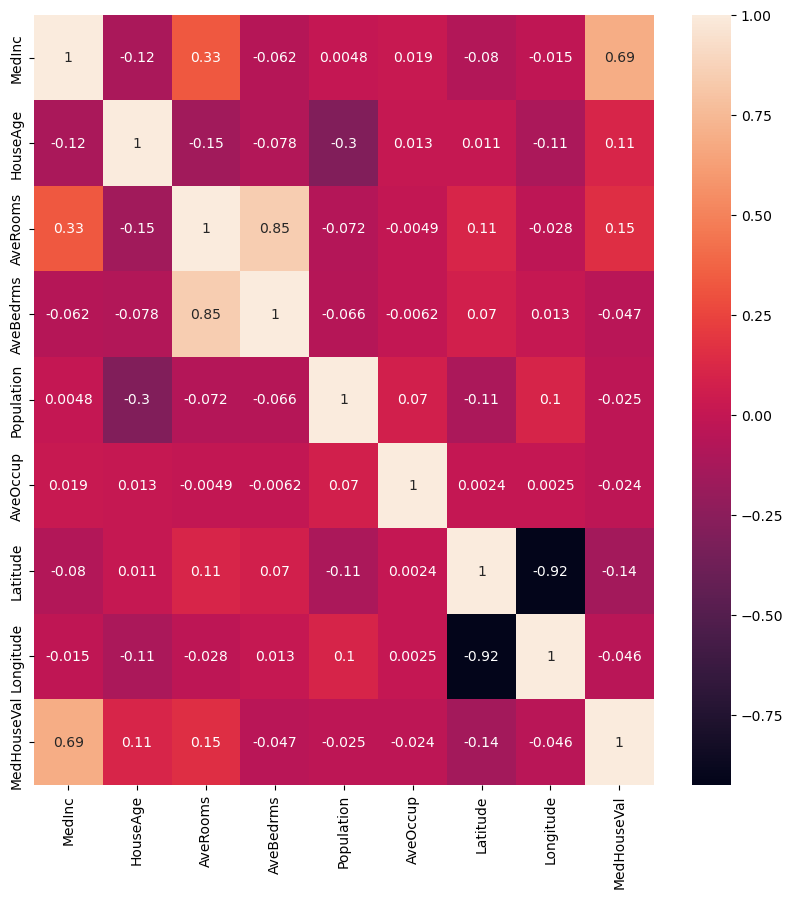

In [22]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True)

<Axes: xlabel='MedInc', ylabel='Count'>

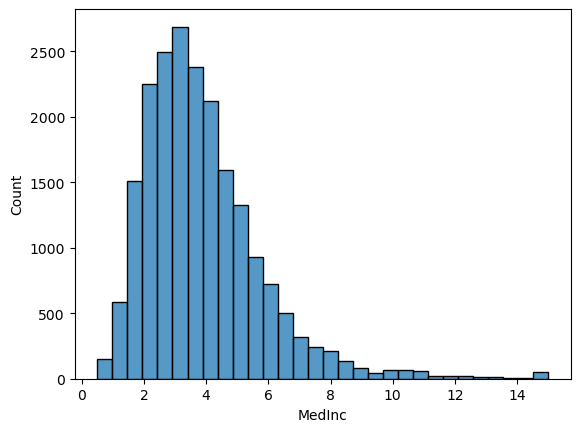

In [23]:
sns.histplot(data=data, x='MedInc', bins=30)

<Axes: xlabel='MedInc', ylabel='Count'>

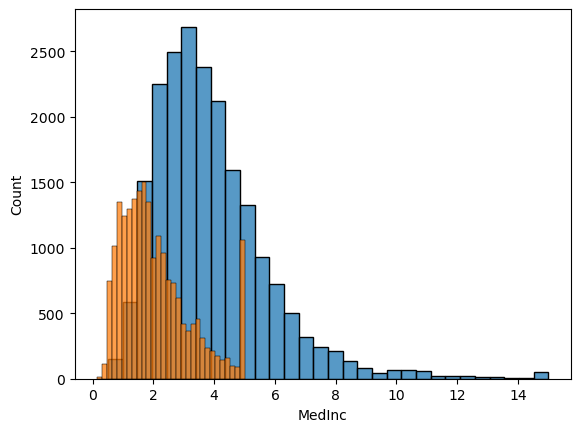

In [24]:
sns.histplot(data=data, x='MedInc', bins=30)
sns.histplot(data=data, x='MedHouseVal', bins=30)

In [25]:
from sklearn.model_selection import train_test_split

feature = data.drop(columns=['MedHouseVal'])
target = data['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.30, random_state=101)

In [27]:
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor()

dtree.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [29]:
predictions = dtree.predict(X_test)
predictions

array([3.636  , 5.00001, 1.53   , ..., 0.682  , 0.43   , 1.775  ],
      shape=(6192,))

In [30]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

print('Root mean squared error of decision tree regressor is:')
print(root_mean_squared_error(y_test,predictions))

Root mean squared error of decision tree regressor is:
0.7423193195310759


In [31]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

rf.fit(X_train,y_train)
predictions = rf.predict(X_test)
print('Root mean squared error of random forest regressor is:')
print(root_mean_squared_error(y_test,predictions))

Root mean squared error of random forest regressor is:
0.5280263134103372
